# CerebroVision
## Brain Tumor Classification using ResNet50 Transfer Learning


This project classifies brain MRI scans into:
- Glioma
- Meningioma
- No Tumor
- Pituitary

It also uses Grad-CAM for Explainable AI.

**Import Libraries**

In [ ]:
import os
import cv2
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

# 💾 Mount Google Drive

Mount Google Drive to access the dataset, save trained models, and store training history.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 📁 Dataset Preparation

Load the training and testing datasets using `ImageDataGenerator`.

The training dataset uses data augmentation to improve generalization, while the testing dataset is only preprocessed for evaluation.

In [ ]:
!cp -r /content/drive/MyDrive/CerebroVision/data /content/

In [ ]:
train_dir = "/content/data/Training"
test_dir = "/content/data/Testing"

In [ ]:
print("Training Classes:", os.listdir(train_dir))
print("Testing Classes:", os.listdir(test_dir))

Training Classes: ['notumor', 'pituitary', 'meningioma', 'glioma']
Testing Classes: ['notumor', 'pituitary', 'meningioma', 'glioma']


# ⚙️ Project Configuration

In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
print(train_generator.samples)
print(test_generator.samples)

5600
1600


# 🏗️ Build ResNet50 Model

Load the pre-trained ResNet50 model and customize it for four-class brain tumor classification by adding a custom classification head.

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(4, activation="softmax")(x)

In [ ]:
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🎯 Configure Callbacks

Use callbacks such as Early Stopping, Model Checkpointing, and Learning Rate Scheduling to improve training performance and prevent overfitting.

In [ ]:


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/CerebroVision/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# 🚀 Initial Model Training

Train the custom classification head while keeping the ResNet50 backbone frozen.

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5600 - loss: 1.1356
Epoch 1: val_accuracy improved from None to 0.78938, saving model to /content/drive/MyDrive/CerebroVision/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CerebroVision/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 99s 503ms/step - accuracy: 0.6929 - loss: 0.7975 - val_accuracy: 0.7894 - val_loss: 0.5739 - learning_rate: 1.0000e-04
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8183 - loss: 0.4885
Epoch 2: val_accuracy improved from 0.78938 to 0.82250, saving model to /content/drive/MyDrive/CerebroVision/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CerebroVision/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 485ms/step - accuracy: 0.8291 - loss: 0.4665 - val_accuracy: 0.8225 - val_loss: 0.5146 - learning_rate: 1.0000e-04
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8449 - loss: 0.4084
Epoch 3: val_

**INITIAL MODEL PERFORMANCE**

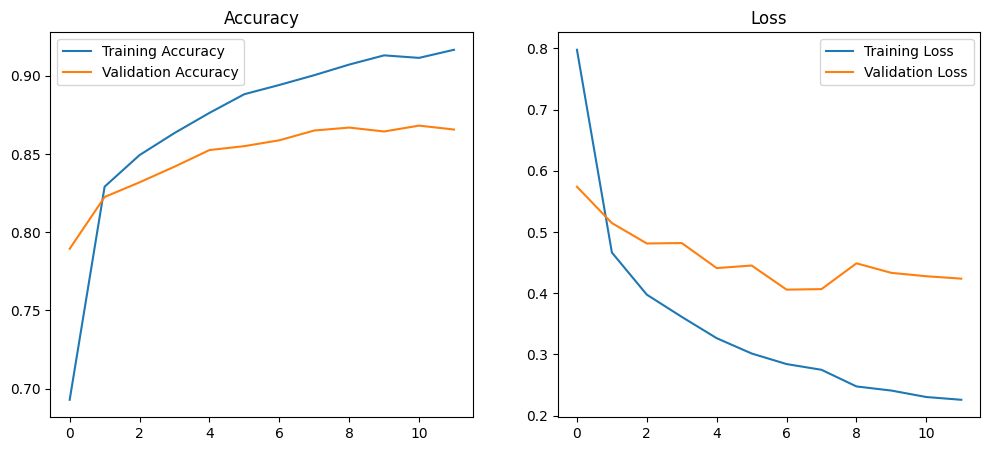

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.title("Accuracy")

plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()

plt.title("Loss")

plt.show()

# 🔧 Fine-Tuning the Model

Unfreeze the final convolutional block of ResNet50 and continue training using a smaller learning rate to improve feature learning.

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/CerebroVision/best_model.keras")

In [ ]:
base_model = model.layers[0]

print(base_model.name)

input_layer_4


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

0 input_layer_4 InputLayer
1 conv1_pad ZeroPadding2D
2 conv1_conv Conv2D
3 conv1_bn BatchNormalization
4 conv1_relu Activation
5 pool1_pad ZeroPadding2D
6 pool1_pool MaxPooling2D
7 conv2_block1_1_conv Conv2D
8 conv2_block1_1_bn BatchNormalization
9 conv2_block1_1_relu Activation
10 conv2_block1_2_conv Conv2D
11 conv2_block1_2_bn BatchNormalization
12 conv2_block1_2_relu Activation
13 conv2_block1_0_conv Conv2D
14 conv2_block1_3_conv Conv2D
15 conv2_block1_0_bn BatchNormalization
16 conv2_block1_3_bn BatchNormalization
17 conv2_block1_add Add
18 conv2_block1_out Activation
19 conv2_block2_1_conv Conv2D
20 conv2_block2_1_bn BatchNormalization
21 conv2_block2_1_relu Activation
22 conv2_block2_2_conv Conv2D
23 conv2_block2_2_bn BatchNormalization
24 conv2_block2_2_relu Activation
25 conv2_block2_3_conv Conv2D
26 conv2_block2_3_bn BatchNormalization
27 conv2_block2_add Add
28 conv2_block2_out Activation
29 conv2_block3_1_conv Conv2D
30 conv2_block3_1_bn BatchNormalization
31 conv2_block3_1_

In [ ]:
for layer in model.layers:
    layer.trainable = False

In [ ]:
for layer in model.layers[143:]:
    layer.trainable = True

In [ ]:
for layer in model.layers[140:]:
    print(layer.name, layer.trainable)

conv4_block6_3_bn False
conv4_block6_add False
conv4_block6_out False
conv5_block1_1_conv True
conv5_block1_1_bn True
conv5_block1_1_relu True
conv5_block1_2_conv True
conv5_block1_2_bn True
conv5_block1_2_relu True
conv5_block1_0_conv True
conv5_block1_3_conv True
conv5_block1_0_bn True
conv5_block1_3_bn True
conv5_block1_add True
conv5_block1_out True
conv5_block2_1_conv True
conv5_block2_1_bn True
conv5_block2_1_relu True
conv5_block2_2_conv True
conv5_block2_2_bn True
conv5_block2_2_relu True
conv5_block2_3_conv True
conv5_block2_3_bn True
conv5_block2_add True
conv5_block2_out True
conv5_block3_1_conv True
conv5_block3_1_bn True
conv5_block3_1_relu True
conv5_block3_2_conv True
conv5_block3_2_bn True
conv5_block3_2_relu True
conv5_block3_3_conv True
conv5_block3_3_bn True
conv5_block3_add True
conv5_block3_out True
global_average_pooling2d_2 True
dense_4 True
dropout_2 True
dense_5 True


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 💾 Save the Best Model

Save the best-performing model based on validation accuracy for future inference and deployment.

In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9834 - loss: 0.0489
Epoch 1: val_accuracy improved from None to 0.94250, saving model to /content/drive/MyDrive/CerebroVision/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CerebroVision/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 100s 483ms/step - accuracy: 0.9834 - loss: 0.0507 - val_accuracy: 0.9425 - val_loss: 0.3462 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9910 - loss: 0.0347
Epoch 2: val_accuracy improved from 0.94250 to 0.94375, saving model to /content/drive/MyDrive/CerebroVision/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CerebroVision/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 499ms/step - accuracy: 0.9887 - loss: 0.0389 - val_accuracy: 0.9438 - val_loss: 0.3450 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9890 - loss: 0.0351
Epoch 3: val

# 🧪 Model Evaluation

Evaluate the trained model on the unseen test dataset to measure its generalization performance.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.9519 - loss: 0.3318
Test Loss : 0.3318
Test Accuracy : 0.9519


In [ ]:
import numpy as np

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
  meningioma       0.90      0.98      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[329  45  25   1]
 [  0 394   0   6]
 [  0   0 400   0]
 [  0   0   0 400]]


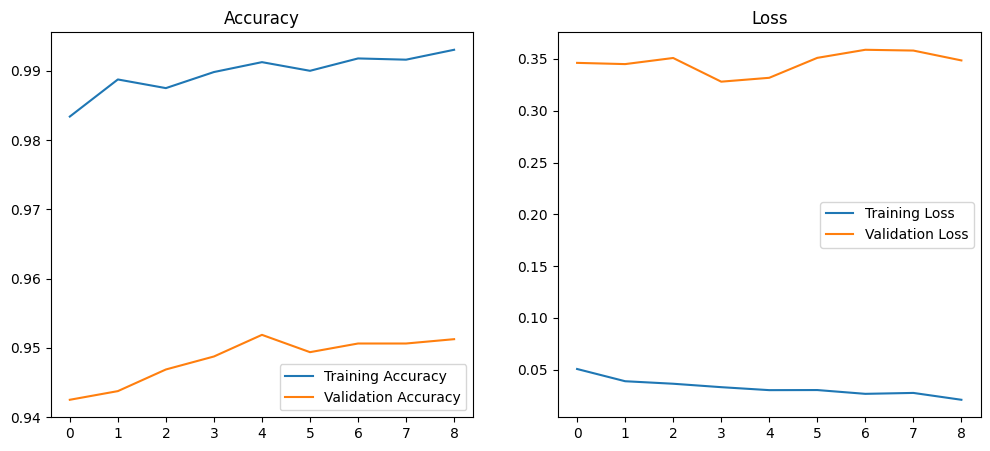

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.title("Accuracy")

plt.subplot(1,2,2)

plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.legend()

plt.title("Loss")

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/CerebroVision/best_model.keras")

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.9519 - loss: 0.3318
Test Loss: 0.3318
Test Accuracy: 0.9519


# 🔥Grad-CAM

Generate Grad-CAM visualizations using the **tf-keras-vis** library to explain the model's predictions by highlighting the most influential regions of the MRI scan.

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer_4 InputLayer
1 conv1_pad ZeroPadding2D
2 conv1_conv Conv2D
3 conv1_bn BatchNormalization
4 conv1_relu Activation
5 pool1_pad ZeroPadding2D
6 pool1_pool MaxPooling2D
7 conv2_block1_1_conv Conv2D
8 conv2_block1_1_bn BatchNormalization
9 conv2_block1_1_relu Activation
10 conv2_block1_2_conv Conv2D
11 conv2_block1_2_bn BatchNormalization
12 conv2_block1_2_relu Activation
13 conv2_block1_0_conv Conv2D
14 conv2_block1_3_conv Conv2D
15 conv2_block1_0_bn BatchNormalization
16 conv2_block1_3_bn BatchNormalization
17 conv2_block1_add Add
18 conv2_block1_out Activation
19 conv2_block2_1_conv Conv2D
20 conv2_block2_1_bn BatchNormalization
21 conv2_block2_1_relu Activation
22 conv2_block2_2_conv Conv2D
23 conv2_block2_2_bn BatchNormalization
24 conv2_block2_2_relu Activation
25 conv2_block2_3_conv Conv2D
26 conv2_block2_3_bn BatchNormalization
27 conv2_block2_add Add
28 conv2_block2_out Activation
29 conv2_block3_1_conv Conv2D
30 conv2_block3_1_bn BatchNormalization
31 conv2_block3_1_

In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.6 MB/s eta 0:00:00


In [ ]:
gradcam = Gradcam(
    model,
    model_modifier=ReplaceToLinear(),
    clone=True
)

In [ ]:
img, label = next(test_generator)
img = img[:1]

In [ ]:
prediction = model.predict(img)

predicted_class = np.argmax(prediction[0])

print("Predicted Class:", predicted_class)
print("Confidence:", prediction[0][predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: 1
Confidence: 0.99989915


In [ ]:
score = CategoricalScore(predicted_class)

cam = gradcam(score, img)

cam = cam[0]

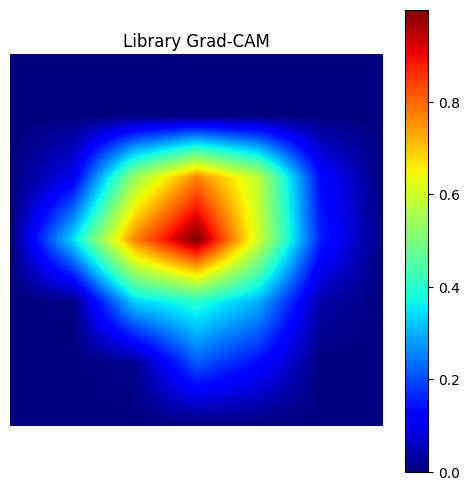

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(cam, cmap="jet")
plt.colorbar()
plt.title("Library Grad-CAM")
plt.axis("off")
plt.show()

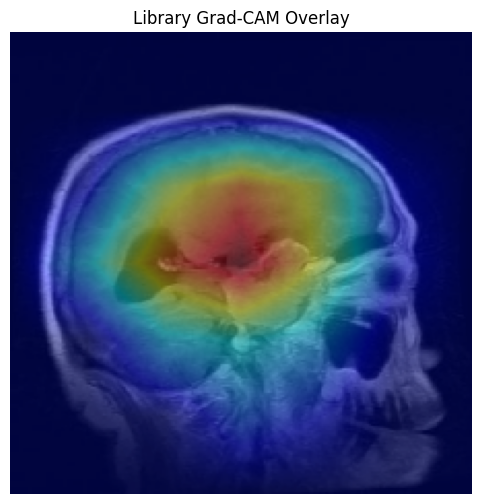

In [ ]:
heatmap = cv2.resize(cam, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

original = img[0].copy()

original -= original.min()
original /= original.max()

overlay = cv2.addWeighted(
    np.uint8(original*255),
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Library Grad-CAM Overlay")
plt.show()

In [ ]:
prediction = model.predict(img)

print("Probabilities:")
for i, p in enumerate(prediction[0]):
    print(i, class_labels[i], f"{p:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Probabilities:
0 glioma 0.0039
1 meningioma 0.9961
2 notumor 0.0000
3 pituitary 0.0000


# 🧠 Multiple MRI Predictions

Test the trained model on different MRI images and display:

- Ground Truth
- Predicted Class
- Prediction Confidence
- Grad-CAM Heatmap
- Grad-CAM Overlay

Image Index      : 7
Ground Truth     : meningioma
Prediction       : meningioma
Confidence       : 99.74%


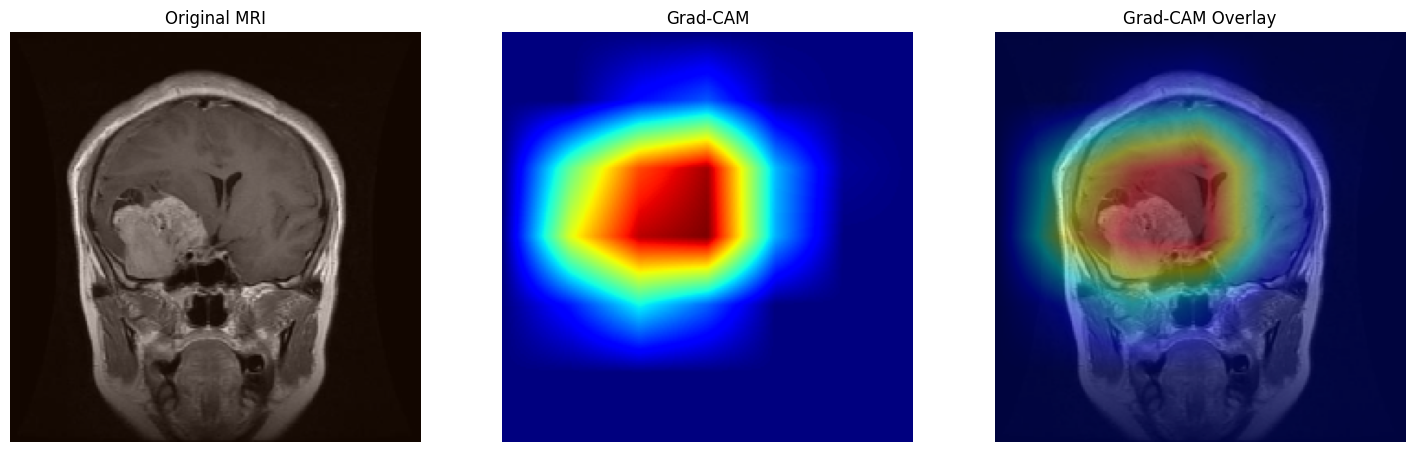

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

# GET ONE BATCH

images, labels = next(test_generator)

# Change image index here (0-31)
idx = 7

img = images[idx:idx+1]

true_class = np.argmax(labels[idx])
# PREDICTION

prediction = model.predict(img, verbose=0)

pred_class = np.argmax(prediction[0])

confidence = prediction[0][pred_class]
# DISPLAY IMAGE

display_img = images[idx].copy()

display_img -= display_img.min()
display_img /= display_img.max()

# PRINT RESULTS

print("="*45)
print(f"Image Index      : {idx}")
print(f"Ground Truth     : {class_labels[true_class]}")
print(f"Prediction       : {class_labels[pred_class]}")
print(f"Confidence       : {confidence*100:.2f}%")
print("="*45)

# LIBRARY GRADCAM

gradcam = Gradcam(
    model,
    model_modifier=ReplaceToLinear(),
    clone=True
)

score = CategoricalScore(pred_class)

cam = gradcam(score, img)

cam = cam[0]

# HEATMAP

heatmap = cv2.resize(cam, (224,224))

heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

original = np.uint8(display_img*255)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap,
    0.4,
    0
)

# SHOW EVERYTHING

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(display_img)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam,cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

# ✅ Conclusion

The ResNet50-based transfer learning model successfully classifies brain MRI scans into four categories with high accuracy.

Key Achievements:

- ✅ Transfer Learning using ResNet50
- ✅ Fine-Tuning
- ✅ 95.19% Test Accuracy
- ✅ Explainable AI using Grad-CAM
- ✅ Multi-class Brain Tumor Classification